In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.config import ZoneConfig, ColumnSchema, ModelConfig
from src.zones import _SHARED_COMMODITY,_SHARED_WEATHER,_SHARED_ENTSO,ZONES
from src.data import load_and_validate, report_missingness, impute, summarize_validated_data
from src.plotting import plot_price_distribution, plot_feature_summary, plot_hourly_errors, plot_timeseries_actual_vs_predicted,plot_regime_profiles, plot_error_distribution,plot_regime_probabilities, plot_confusion_matrix, plot_single_day_diagnostics
from src.features import build_daily_features, build_price_pivot_lag1
from src.model import compute_spike_threshold, build_leaf_masks, fit_pca_and_fcm, assemble_regime_labels, train_classifier_l2, train_classifier_l1, train_expert_models, predict_fold, run_fold, load_or_train,walk_forward
from src.evaluation import wape,mae, regime_metrics, fold_metrics, worst_best_days_wape,worst_best_days_mae, reconstruct_actual_regimes, confusion_matrix_l1, confusion_matrix_l2


## Section 1 - Data Loading and Validation
### Load and Parse

Before any transformation, the raw data must be validated against four properties: timezone consistency, unbroken hourly frequency, absence of duplicate timestamps and acceptable data quality per column.

### Frequency and Gap Check

Electricity price data should have exactly one observation per UTC hour. Missing hours and duplicate hours must be identified and quantified before imputation decisions are made.

In [2]:
df_hourly = load_and_validate(ZONES["DK1"])


Shape:        (28373, 13)
Index min:    2023-01-01 00:00:00+00:00
Index max:    2026-03-28 12:00:00+00:00
Index dtype:  datetime64[ns, UTC]
Monotonic:    True
Expected hours:   28,381
Actual hours:     28,373
Missing hours:    8
Duplicate hours:  0

5 gap block(s):
  2023-10-29 00:00:00+00:00 -> 2023-10-29 01:00:00+00:00  (2h)
  2023-12-30 23:00:00+00:00 -> 2023-12-30 23:00:00+00:00  (1h)
  2024-10-27 00:00:00+00:00 -> 2024-10-27 01:00:00+00:00  (2h)
  2024-12-30 23:00:00+00:00 -> 2024-12-30 23:00:00+00:00  (1h)
  2025-10-26 00:00:00+00:00 -> 2025-10-26 01:00:00+00:00  (2h)

After reindex: (28381, 13)


### Missingness Report

Each column's missingness rate determines the imputation strategy. Short gaps in smooth variables (temperature, wind) are suitable for linear interpolation. Price gaps require more care because electricity prices are not smooth, here forward-fill is inappropriate.

In [3]:
report_missingness(df_hourly)

Missingness table:
                                   null_count  null_pct
wind_solar_forecast_Wind Onshore          174     0.613
wind_solar_forecast_Wind Offshore         131     0.462
generation_forecast                       107     0.377
wind_solar_forecast_Solar                  59     0.208
load_forecast_Forecasted Load              11     0.039
solar_radiation_W                           8     0.028
precipitation_mm                            8     0.028
wind_speed_10m                              8     0.028
temperature_2m                              8     0.028
price_eur_mwh                               8     0.028
brent_usd_bbl                               8     0.028
ttf_gas_eur_mwh                             8     0.028
co2_eua_eur_tonne                           8     0.028


In [4]:
df_hourly = impute(df_hourly,ZONES["DK1"])

Missingness table:
                                   null_count  null_pct
wind_solar_forecast_Wind Onshore          174     0.613
wind_solar_forecast_Wind Offshore         131     0.462
generation_forecast                       107     0.377
wind_solar_forecast_Solar                  59     0.208
load_forecast_Forecasted Load              11     0.039
solar_radiation_W                           8     0.028
precipitation_mm                            8     0.028
wind_speed_10m                              8     0.028
temperature_2m                              8     0.028
price_eur_mwh                               8     0.028
brent_usd_bbl                               8     0.028
ttf_gas_eur_mwh                             8     0.028
co2_eua_eur_tonne                           8     0.028

Price: interpolated 8 gaps (<= 3h).
Weather temperature_2m: interpolated 8, 0 remaining.
Weather wind_speed_10m: interpolated 8, 0 remaining.
Weather precipitation_mm: interpolated 8, 0 remaining.

### Outlier Inspection

Extreme electricity prices are not errors. Scarcity events and renewable surplus events produce genuinely extreme values that carry important regime signal. The goal here is to identify and inspect.

In [5]:
df_hourly

,price_eur_mwh,temperature_2m,wind_speed_10m,precipitation_mm,solar_radiation_W,ttf_gas_eur_mwh,co2_eua_eur_tonne,brent_usd_bbl,load_forecast_Forecasted Load,wind_solar_forecast_Solar,wind_solar_forecast_Wind Offshore,wind_solar_forecast_Wind Onshore,generation_forecast
2023-01-01 00:00:00+00:00,1.3800,6.421936,2.031311,1.401962,0.00000,76.315002,80.945000,85.910004,2084.0,0.000000,146.000000,639.250000,974.44
2023-01-01 01:00:00+00:00,0.0900,6.482971,1.516203,1.275362,0.00000,76.315002,80.945000,85.910004,2059.0,0.000000,328.420000,734.830000,1165.29
2023-01-01 02:00:00+00:00,0.0800,6.467590,1.527486,0.957147,0.00000,76.315002,80.945000,85.910004,2001.0,0.000000,376.420000,869.960000,1436.83
2023-01-01 03:00:00+00:00,0.0500,6.472961,1.431147,0.756716,0.00000,76.315002,80.945000,85.910004,1969.0,0.000000,428.710000,1046.500000,1516.86
2023-01-01 04:00:00+00:00,0.0000,6.375794,1.656783,0.636455,0.00000,76.315002,80.945000,85.910004,1973.0,0.010000,716.920000,1307.670000,1497.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-28 08:00:00+00:00,44.9075,5.445007,4.822319,0.028763,188.68387,55.217999,67.404999,108.010002,2857.0,908.853333,477.666666,466.500000,2581.14
2026-03-28 09:00:00+00:00,17.5825,5.983551,4.862987,0.020565,297.27637,55.217999,67.404999,108.010002,2983.0,1292.033333,418.333333,507.333333,2882.82
2026-03-28 10:00:00+00:00,7.6475,6.421875,5.228496,0.017166,362.28170,55.217999,67.404999,108.010002,3059.0,1613.998333,391.666666,628.500000,3215.60
2026-03-28 11:00:00+00:00,6.6975,6.838928,5.233797,0.023512,451.17972,55.217999,67.404999,108.010002,3137.0,1735.853333,388.000000,708.333333,3416.17


p0.1 threshold:  -37.76 EUR/MWh
p99.9 threshold: 403.88 EUR/MWh
High outliers (>403.9): 29
Low outliers  (<-37.8):  29

High outliers (first 20):
                           price_eur_mwh
2023-09-11 17:00:00+00:00         524.27
2023-09-11 18:00:00+00:00         448.13
2024-11-05 16:00:00+00:00         472.99
2024-11-05 17:00:00+00:00         431.02
2024-11-06 16:00:00+00:00         550.00
2024-12-11 15:00:00+00:00         437.87
2024-12-11 16:00:00+00:00         434.86
2024-12-12 06:00:00+00:00         599.99
2024-12-12 07:00:00+00:00         655.60
2024-12-12 08:00:00+00:00         646.76
2024-12-12 09:00:00+00:00         543.83
2024-12-12 10:00:00+00:00         465.36
2024-12-12 11:00:00+00:00         404.99
2024-12-12 12:00:00+00:00         415.30
2024-12-12 13:00:00+00:00         490.34
2024-12-12 14:00:00+00:00         668.49
2024-12-12 15:00:00+00:00         818.98
2024-12-12 16:00:00+00:00         936.28
2024-12-12 17:00:00+00:00         674.18
2024-12-12 18:00:00+00:00         

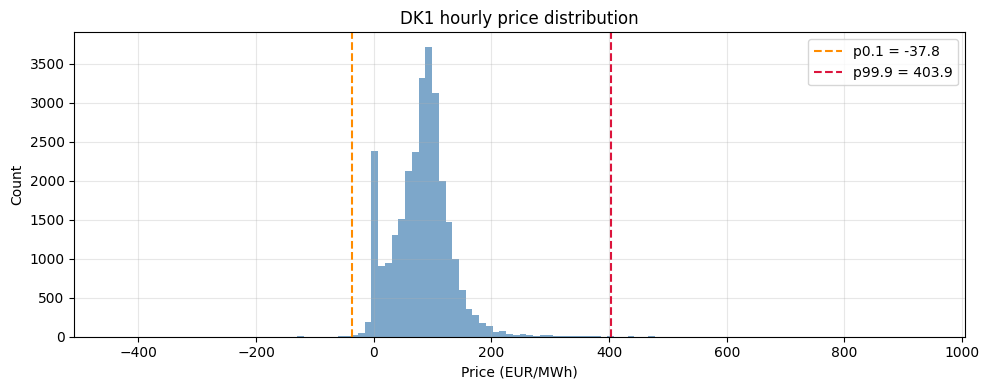

Saved: results/price_distribution.png

Negative price hours: 1,104  (3.89% of total)


In [6]:
plot_price_distribution(df_hourly, ZONES["DK1"])

### Validated Data Summary

The data is now clean and ready for feature engineering.

In [7]:
summarize_validated_data(df_hourly, ZONES["DK1"])

=== Validated Data Summary ===
Total hours:           28,381
Total days:            1,183
Date range:            2023-01-01 -> 2026-03-28
Price mean:            81.06 EUR/MWh
Price std:             49.88 EUR/MWh
Price min:             -440.10 EUR/MWh
Price max:             936.28 EUR/MWh
Negative price hours:  3.89%

  temperature_2m               mean=9.334  std=5.923
  wind_speed_10m               mean=5.609  std=2.636
  precipitation_mm             mean=0.109  std=0.233
  solar_radiation_W            mean=120.035  std=190.282
  ttf_gas_eur_mwh              mean=37.659  std=8.930
  co2_eua_eur_tonne            mean=72.663  std=9.356
  brent_usd_bbl                mean=76.732  std=8.885
  load_forecast_Forecasted Load mean=2611.408  std=474.948
  wind_solar_forecast_Solar    mean=276.247  std=451.571
  wind_solar_forecast_Wind Offshore mean=568.574  std=296.421
  wind_solar_forecast_Wind Onshore mean=915.249  std=697.409
  generation_forecast          mean=2468.265  std=1062.162

df_h

### Feature Engineering Design

Every feature for day T is constructed exclusively from information observable before noon on day T-1, the operational forecast window for the day-ahead auction. Day T-1 prices cleared at noon on day T-2 and are fully observable. Weather features for day T use ERA5 actuals as a proxy for the operational forecast; at inference time these will be replaced by WeatherAPI forecast values. Commodity features use the settlement price of day T-1.

**TO-DO: Replace ERA5 entirely by WeatherAPI**

Features fall into six groups: lag-1 price statistics, momentum, persistence signals, commodity signals, weather signals, and calendar encodings. Each group captures a distinct dimension of the information set available at forecast time.

The function accepts an optional spike_threshold parameter. When None, spike_streak_length is omitted from the output, handling the bootstrap case where the threshold has not yet been computed.

### build_daily_features() Function

This function does feature construction for the clustering part. It is called identically by the training pipeline, the walk-forward loop and the inference app. Any change here propagates everywhere.

The function is applied to the full hourly dataset here to produce the master daily dataframe. Walk-forward folds will slice this dataframe by date.

In [8]:
df_daily = build_daily_features(df_hourly, ZONES["DK1"],spike_threshold=None)

print(f"Shape:          {df_daily.shape}")
print(f"Date range:     {df_daily.index.min().date()} -> {df_daily.index.max().date()}")
print(f"Missing values: {df_daily.isnull().sum().sum()}")
print(f"Columns ({len(df_daily.columns)}):")
for c in df_daily.columns:
    print(f"  {c}")
print()
print(df_daily.describe().round(3).to_string())
print("\nFirst 5 rows:")
print(df_daily.head().to_string())


Note: spike_threshold is None -- spike_streak_length omitted.
build_daily_features: dropped 5 rows. Remaining: 1178 (2023-01-05 -> 2026-03-27)
Shape:          (1178, 85)
Date range:     2023-01-05 -> 2026-03-27
Missing values: 0
Columns (85):
  price_mean_lag1
  price_std_lag1
  price_min_lag1
  price_max_lag1
  price_neg_frac_lag1
  was_negative_lag1
  price_range_lag1
  pivot_hour_peak_lag1
  pivot_hour_trough_lag1
  pivot_peak_sin
  pivot_peak_cos
  pivot_trough_sin
  pivot_trough_cos
  price_roll3_mean
  price_roll7_mean
  neg_streak_length
  ttf_lag1
  ttf_return_1d
  ttf_return_3d
  ttf_roll7_std
  co2_lag1
  co2_return_1d
  brent_return_3d
  spark_spread_proxy
  co2_gas_ratio
  wind_mean_t
  temp_mean_t
  solar_mean_t
  precip_sum_t
  temp_sq
  wind_power_proxy
  wind_chill
  supply_margin
  conventional_gen
  load_overnight
  load_morning
  load_midday
  load_evening
  load_night
  solar_overnight
  solar_morning
  solar_midday
  solar_evening
  solar_night
  wind_off_overnight

### 24-Hour Price Pivot Matrix

The 24-hour price curve of each day encodes intraday shape information that scalar aggregates cannot capture. This pivot matrix is used as part of the combined feature vector fed into PCA before clustering. It represents day T-1 shape (the actual price curve that cleared yesterday).

In [9]:
price_pivot_lag1 = build_price_pivot_lag1(df_hourly, df_daily, ZONES["DK1"])

price_pivot_lag1 shape: (1178, 24)
NaN count:              0

First 3 rows:
               h00    h01    h02    h03    h04    h05     h06     h07     h08     h09     h10     h11     h12     h13     h14     h15     h16     h17     h18     h19     h20     h21     h22     h23
date                                                                                                                                                                                                 
2023-01-05   70.67  40.00   8.68   0.85  11.02  61.02   79.20   84.20   83.32   70.07   79.74   80.89   79.72   80.22   79.74   80.82   86.16   72.28   66.61   43.20   31.25   34.96    9.09    0.09
2023-01-06    0.10   0.12   0.12   2.23  10.07  61.04   87.19   95.84  125.55  131.92  143.07  140.91  142.58  151.03  159.48  172.73  194.70  194.67  177.98  163.99  152.00  144.64  127.00  107.21
2023-01-07  101.10  96.73  82.34  81.93  84.03  97.25  106.51  120.70  116.86  112.85  113.37  115.00  109.78  119.71  125.83  139.5

In [10]:
price_pivot_lag1

,h00,h01,h02,h03,h04,h05,h06,h07,h08,h09,...,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23
date,,,,,,,,,,,,,,,,,,,,,
2023-01-05,70.6700,40.0000,8.6800,0.8500,11.0200,61.0200,79.2000,84.2000,83.3200,70.0700,...,79.7400,80.8200,86.1600,72.280,66.6100,43.2000,31.2500,34.9600,9.0900,0.0900
2023-01-06,0.1000,0.1200,0.1200,2.2300,10.0700,61.0400,87.1900,95.8400,125.5500,131.9200,...,159.4800,172.7300,194.7000,194.670,177.9800,163.9900,152.0000,144.6400,127.0000,107.2100
2023-01-07,101.1000,96.7300,82.3400,81.9300,84.0300,97.2500,106.5100,120.7000,116.8600,112.8500,...,125.8300,139.5700,155.2200,150.090,146.1500,139.1000,131.8000,129.9400,121.3000,97.1500
2023-01-08,98.4300,96.0500,87.9700,82.9900,83.5900,90.7600,103.2100,111.8600,112.0000,100.0000,...,85.5600,94.1000,96.8100,99.520,94.5800,87.8600,61.4700,50.0000,38.2500,10.9300
2023-01-09,9.0700,9.1000,4.1600,5.5800,9.9200,9.0200,16.4700,49.4200,82.8000,93.7000,...,103.6400,109.1100,118.0400,122.610,109.1100,103.9300,98.4300,99.3700,81.3400,75.1300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-23,95.7550,94.2025,95.2600,98.5975,101.6625,100.1050,84.7100,41.3300,8.2975,3.2875,...,11.5125,93.1525,145.6350,174.190,173.3800,164.7300,155.3700,137.3400,133.7200,131.1350
2026-03-24,125.9000,125.1600,128.5875,129.9975,142.5175,174.6775,186.1825,147.6050,108.0000,81.4325,...,114.4525,130.6400,172.5850,257.550,240.9100,199.3875,167.9425,152.1375,137.0025,133.7050
2026-03-25,117.3450,106.6400,95.9250,94.7975,93.0825,78.7675,103.8225,97.4575,70.9050,23.7525,...,20.5600,77.4325,112.8400,126.000,135.5800,101.1000,74.4975,66.1025,22.0975,1.8100


### Feature Visualisation

Verify the features carry the expected economic signals before any modelling.

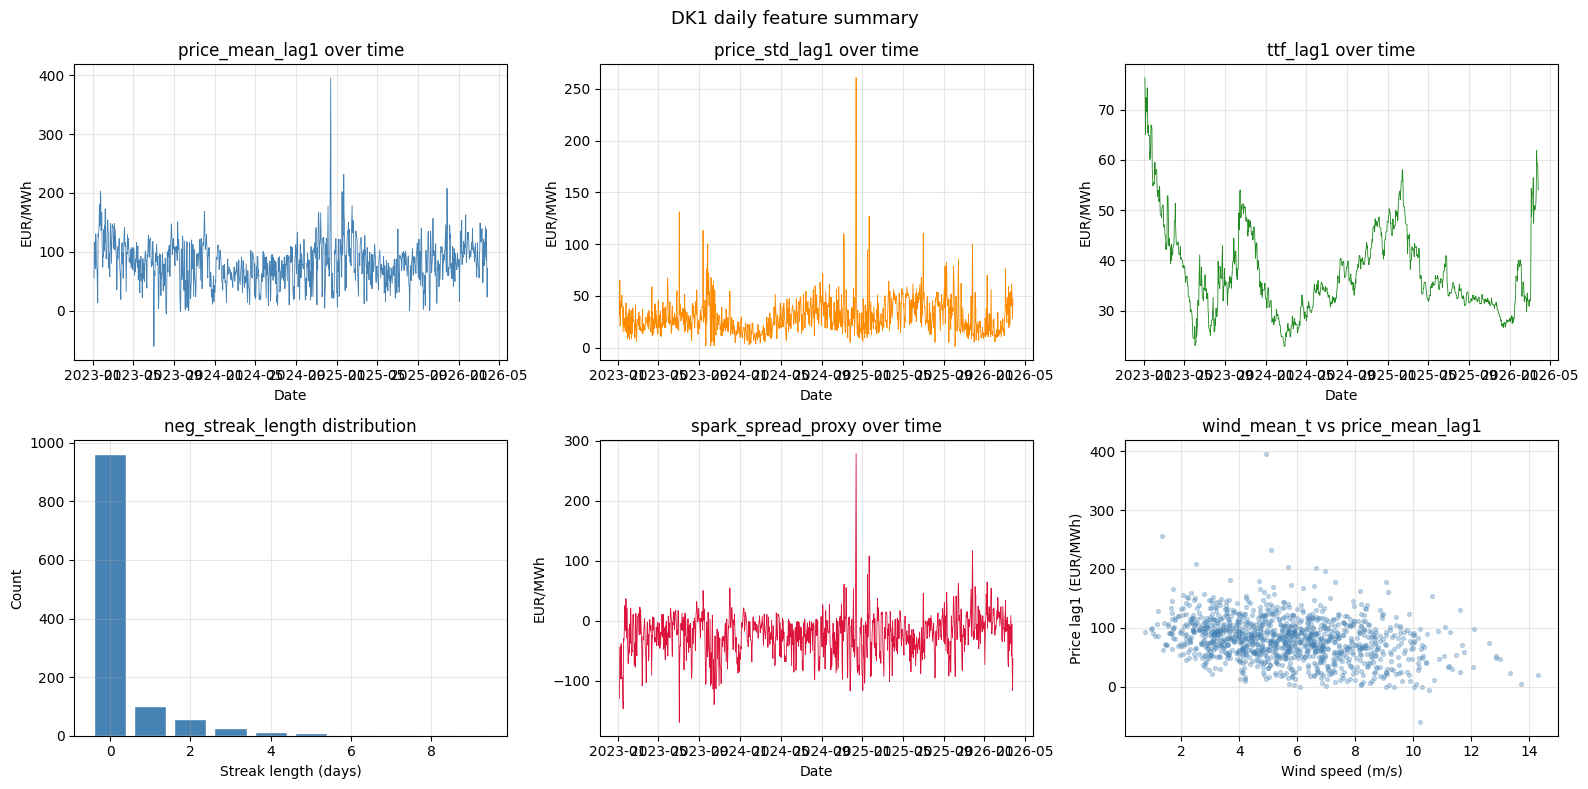

Saved: results/feature_summary.png


In [11]:
plot_feature_summary(df_daily, ZONES["DK1"])

## Section 3 - Walk-Forward Fold Definitions

In [12]:
from src.zones import ZONES
from src.config import ModelConfig
from src import data, features, model, evaluation, plotting


model_cfg = ModelConfig()

fold_def = model_cfg.fold_definitions[0]
tr_s, tr_e, _, _ = fold_def



spike_thr = model.compute_spike_threshold(df_hourly, tr_s, tr_e, ZONES["DK1"], model_cfg)
print(f"Spike threshold: {spike_thr:.2f}")  # compare to original notebook print

df_train = df_daily[(df_daily.index >= tr_s) & (df_daily.index <= tr_e)]
mask_A, mask_B, mask_normal,use_ridge_regime = model.build_leaf_masks(
    df_train, df_hourly, spike_thr, ZONES["DK1"], model_cfg
)
print(f"Leaf A: {mask_A.sum()}, Leaf B: {mask_B.sum()}, Normal: {mask_normal.sum()}")

  Spike threshold (fold): 161.78 EUR/MWh
Spike threshold: 161.78
  Leaf A: 31 days (8.6%) -- WARNING: small bucket, Ridge fallback for expert models
  Leaf B: 100 days (27.7%)
  Normal: 230 days (63.7%)
Leaf A: 31, Leaf B: 100, Normal: 230


In [13]:
pivot_train = price_pivot_lag1.reindex(df_train.index)
scaler, pca, cntr, hard_labels, normal_idx = model.fit_pca_and_fcm(
    df_train, pivot_train, mask_normal, model_cfg
)
regime_labels = model.assemble_regime_labels(
    df_train, mask_A, mask_B, mask_normal, hard_labels, normal_idx
)
print(regime_labels.value_counts().sort_index())  # 0=A, 1=B, 2=C0, 3=C1 counts

  PCA: 17 components retain 0.883 cumulative variance
  FKM C0: 118 days
  FKM C1: 112 days
0     31
1    100
2    118
3    112
Name: count, dtype: int64


In [14]:
# df_results_fold1, models_fold1 = model.run_fold(
#     df_daily, price_pivot_lag1, df_hourly, fold_def, ZONES["DK1"], model_cfg
# )


In [15]:
df_preds, all_fold_models = load_or_train(
    ZONES["DK1"], model_cfg, df_daily, price_pivot_lag1, df_hourly
)

[DK1] Loading cached results from results\cache\DK1
  Loaded 817 predictions, 3 folds


In [16]:
df_loadings = model.extract_pca_loadings(df_daily, price_pivot_lag1, all_fold_models[0])
df_loadings.to_csv(
    model_cfg.results_dir/"pca_loadings_fold_1_DK1.csv"
)

### Naive Baselines

Two baselines are added to df_preds. Naive 1 repeats yesterday's observed 24-hour price curve. Naive 2 averages the same 24-hour slots across the preceding seven days.

In [17]:
# Build full price-by-hour lookup from df_hourly.
_h = df_hourly.copy()
_h["_d"] = pd.to_datetime(_h.index.normalize().date)
_h["_hr"] = _h.index.hour
price_mat_eval = _h.pivot_table(index="_d", columns="_hr", values=ZONES["DK1"].schema.price, aggfunc="mean")
price_mat_eval.index   = pd.to_datetime(price_mat_eval.index)
price_mat_eval.columns = list(range(24))

naive1_arr = np.full((len(df_preds), 24), np.nan)
naive2_arr = np.full((len(df_preds), 24), np.nan)

for i, date in enumerate(pd.to_datetime(df_preds["date"])):
    prev1 = date - pd.Timedelta(days=1)
    if prev1 in price_mat_eval.index:
        naive1_arr[i] = price_mat_eval.loc[prev1].values

    window = pd.date_range(end=date - pd.Timedelta(days=1), periods=7, freq="D")
    valid_w = [d for d in window if d in price_mat_eval.index]
    if valid_w:
        naive2_arr[i] = price_mat_eval.loc[valid_w].mean(axis=0).values

for h in range(24):
    df_preds[f"naive1_h{h:02d}"] = naive1_arr[:, h]
    df_preds[f"naive2_h{h:02d}"] = naive2_arr[:, h]

n1_valid = (~np.isnan(naive1_arr).any(axis=1)).sum()
n2_valid = (~np.isnan(naive2_arr).any(axis=1)).sum()
print(f"Valid naive 1 forecasts: {n1_valid} / {len(df_preds)}")
print(f"Valid naive 2 forecasts: {n2_valid} / {len(df_preds)}")


Valid naive 1 forecasts: 817 / 817
Valid naive 2 forecasts: 817 / 817


### Confusion matrices


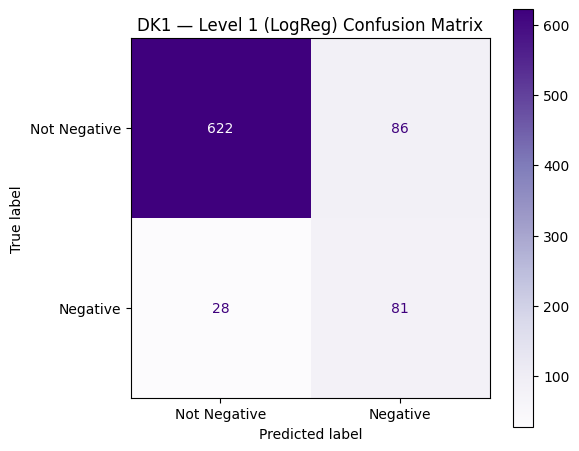


  [LEVEL 1 — TEST SET METRICS]
  ROC-AUC:     0.917
  PR-AUC:      0.596
  Brier Score: 0.099
              precision    recall  f1-score   support

Not Negative       0.96      0.88      0.92       708
    Negative       0.49      0.74      0.59       109

    accuracy                           0.86       817
   macro avg       0.72      0.81      0.75       817
weighted avg       0.89      0.86      0.87       817



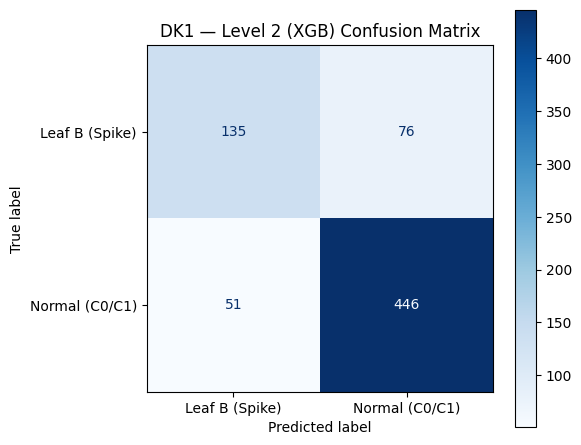


  [LEVEL 2 — TEST SET METRICS (Non-Negative Days)]
                precision    recall  f1-score   support

Leaf B (Spike)       0.73      0.64      0.68       211
Normal (C0/C1)       0.85      0.90      0.88       497

      accuracy                           0.82       708
     macro avg       0.79      0.77      0.78       708
  weighted avg       0.82      0.82      0.82       708



In [18]:
zone_cfg = ZONES["DK1"]
# Step 1: attach ground-truth labels
df_eval = reconstruct_actual_regimes(
    df_preds, df_hourly, all_fold_models, model_cfg, zone_cfg
)

# Step 2: L1 confusion matrix + metrics
cm_l1 = confusion_matrix_l1(df_eval)
fig_l1 = plot_confusion_matrix(
    cm_l1["cm"],
    display_labels=cm_l1["display_labels"],
    title=f"{zone_cfg.zone} — Level 1 (LogReg) Confusion Matrix",
    cmap="Purples",
)
fig_l1.savefig(model_cfg.results_dir / f"cm_l1_{zone_cfg.zone}.png", dpi=120)
plt.show()

print(f"\n{'='*60}")
print(f"  [LEVEL 1 — TEST SET METRICS]")
print(f"{'='*60}")
print(f"  ROC-AUC:     {cm_l1['roc_auc']:.3f}")
print(f"  PR-AUC:      {cm_l1['pr_auc']:.3f}")
print(f"  Brier Score: {cm_l1['brier']:.3f}")
print(cm_l1["classification_report"])

# Step 3: L2 confusion matrix + report
cm_l2 = confusion_matrix_l2(df_eval)
fig_l2 = plot_confusion_matrix(
    cm_l2["cm"],
    display_labels=cm_l2["display_labels"],
    title=f"{zone_cfg.zone} — Level 2 (XGB) Confusion Matrix",
    cmap="Blues",
)
fig_l2.savefig(model_cfg.results_dir / f"cm_l2_{zone_cfg.zone}.png", dpi=120)
plt.show()

print(f"\n{'='*60}")
print(f"  [LEVEL 2 — TEST SET METRICS (Non-Negative Days)]")
print(f"{'='*60}")
print(cm_l2["classification_report"])

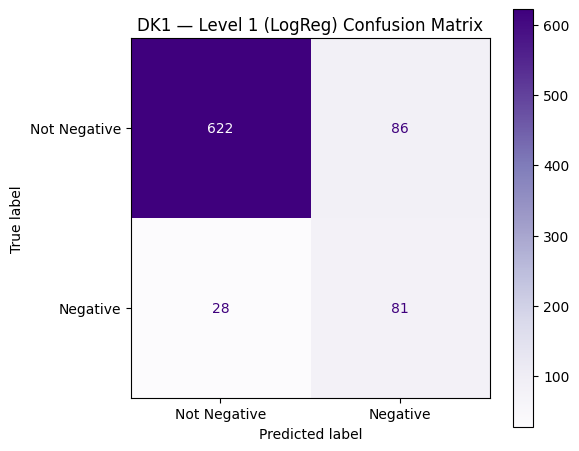

In [19]:
fig_l1

### Overall Metrics

WAPE and MAE are computed over all test hours by flattening the full prediction matrix. NaN values (arising from test days with missing actual prices) are excluded.

In [20]:
act_flat  = df_preds[evaluation.HOUR_COLS].values.ravel()
pred_flat = df_preds[evaluation.PRED_COLS].values.ravel()
n1_flat   = df_preds[evaluation.NAIVE1_COLS].values.ravel()
n2_flat   = df_preds[evaluation.NAIVE2_COLS].values.ravel()

print("=== Overall Metrics ===")
print(f"{'Metric':<12} {'Model':>10} {'Naive 1':>10} {'Naive 2':>10}")
print("-" * 45)
print(f"{'WAPE (%)':<12} {wape(act_flat, pred_flat):>10.2f} {wape(act_flat, n1_flat):>10.2f} {wape(act_flat, n2_flat):>10.2f}")
print(f"{'MAE':<12} {mae(act_flat, pred_flat):>10.2f} {mae(act_flat, n1_flat):>10.2f} {mae(act_flat, n2_flat):>10.2f}")


=== Overall Metrics ===
Metric            Model    Naive 1    Naive 2
---------------------------------------------
WAPE (%)          22.97      36.54      38.35
MAE               18.11      28.81      30.23


### Regime-Level Metrics

Each test day is assigned a dominant regime label as the argmax of its four probability columns. WAPE is suppressed for Regime A (negative-price days) because near-zero or negative denominators make WAPE undefined or misleading.

In [21]:
regime_metrics(df_preds)

  Note: WAPE suppressed for Regime A -- near-zero/negative price denominators.


,regime_name,n,share_pct,wape,mae,naive1_wape,naive2_wape
regime_label,,,,,,,
0,Leaf A (negative),190,23.255814,NaN,18.014118,NaN,NaN
1,Leaf B (spike),178,21.787026,19.672733,22.392981,31.298658,31.655000
2,C0 (normal),245,29.987760,19.503797,15.951591,32.990838,33.137715
3,C1 (normal),204,24.969400,23.023525,17.047818,33.820075,37.900234


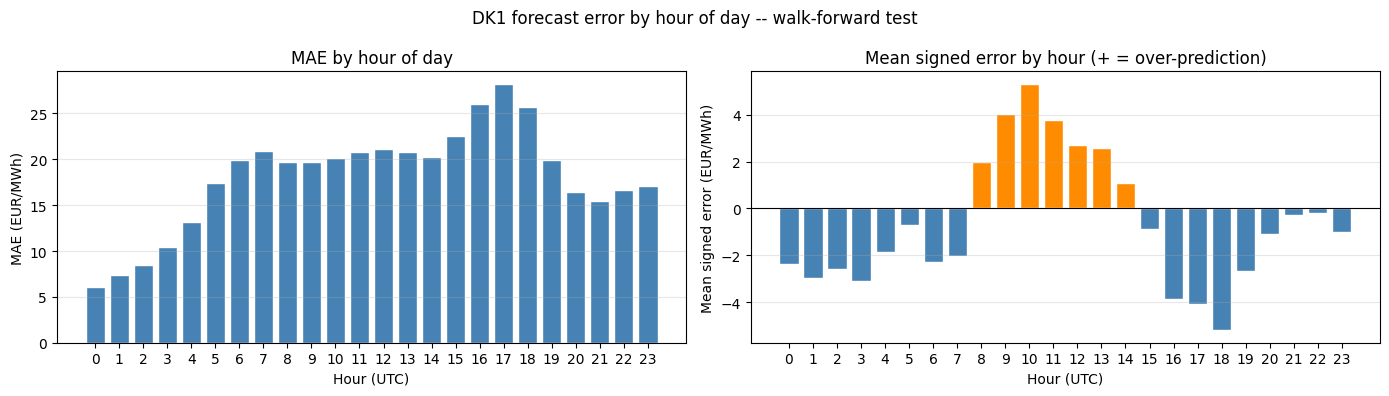

Saved: results/hourly_errors_DK1.png
Hours with highest MAE: ['h17 (28.19)', 'h16 (26.05)', 'h18 (25.74)']


In [22]:
plot_hourly_errors(df_preds, ZONES["DK1"])

### Fold-Level Metrics

Tagging each prediction by fold number allows detection of distribution shift across time: if a later fold shows substantially worse WAPE relative to the naive baseline, it suggests the training regime mix no longer matches the test period.

In [23]:
fold_metrics(df_preds,ModelConfig,ZONES["DK1"])

=== Fold-Level Metrics ===
Fold       N Test period                WAPE% model   WAPE% N1   WAPE% N2
---------------------------------------------------------------------------
1        366 2024-01-01 -> 2024-12-31         26.43      40.66      43.58
2        365 2025-01-01 -> 2025-12-31         21.84      35.77      37.60
3         86 2026-01-01 -> 2026-04-30         16.45      26.81      25.21

Saved: results/walk_forward_predictions_final_DK1.csv  (1008.1 KB)
Columns: 103  |  Rows: 817


## Section 7 - Model Diagnostics

Four diagnostic views examine where and why the model succeeds or fails: a time series overlay coloured by regime, the average 24-hour price curve per regime, the full distribution of prediction errors, and the trajectory of regime probabilities over the test period.

### Actual vs Predicted Daily Mean Price

The daily mean price collapses the 24-hour forecast to one number per day and makes systematic over- or under-prediction visible. The regime strip below the main panel shows the dominant regime assigned by the classifier on each test day.

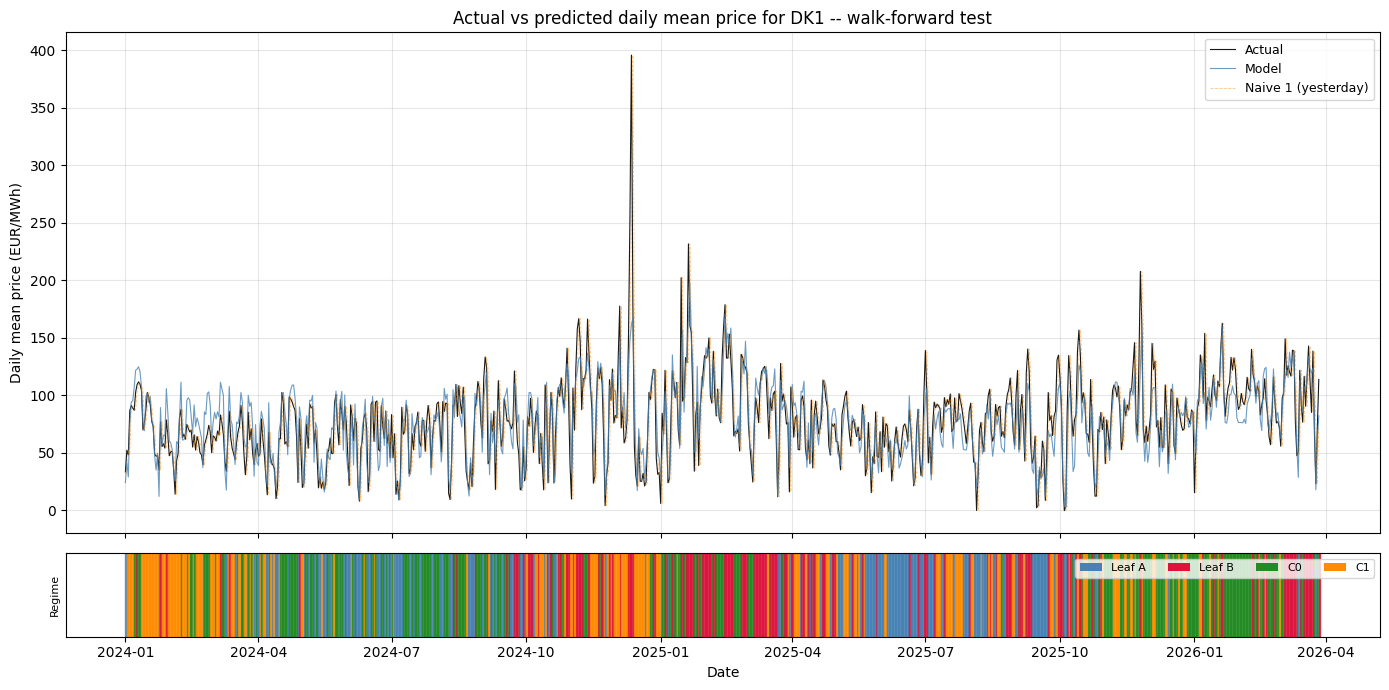

Saved: results/timeseries_actual_vs_predicted_DK1.png


In [24]:
plot_timeseries_actual_vs_predicted(df_preds,ZONES["DK1"])

### Average 24-Hour Profile per Regime

Comparing the mean actual curve against the mean predicted curve within each regime reveals whether the expert models have learned the correct intraday shape. A systematic offset across all hours points to a level bias; a shape mismatch at specific hours points to a structural deficiency in the features available for those periods.

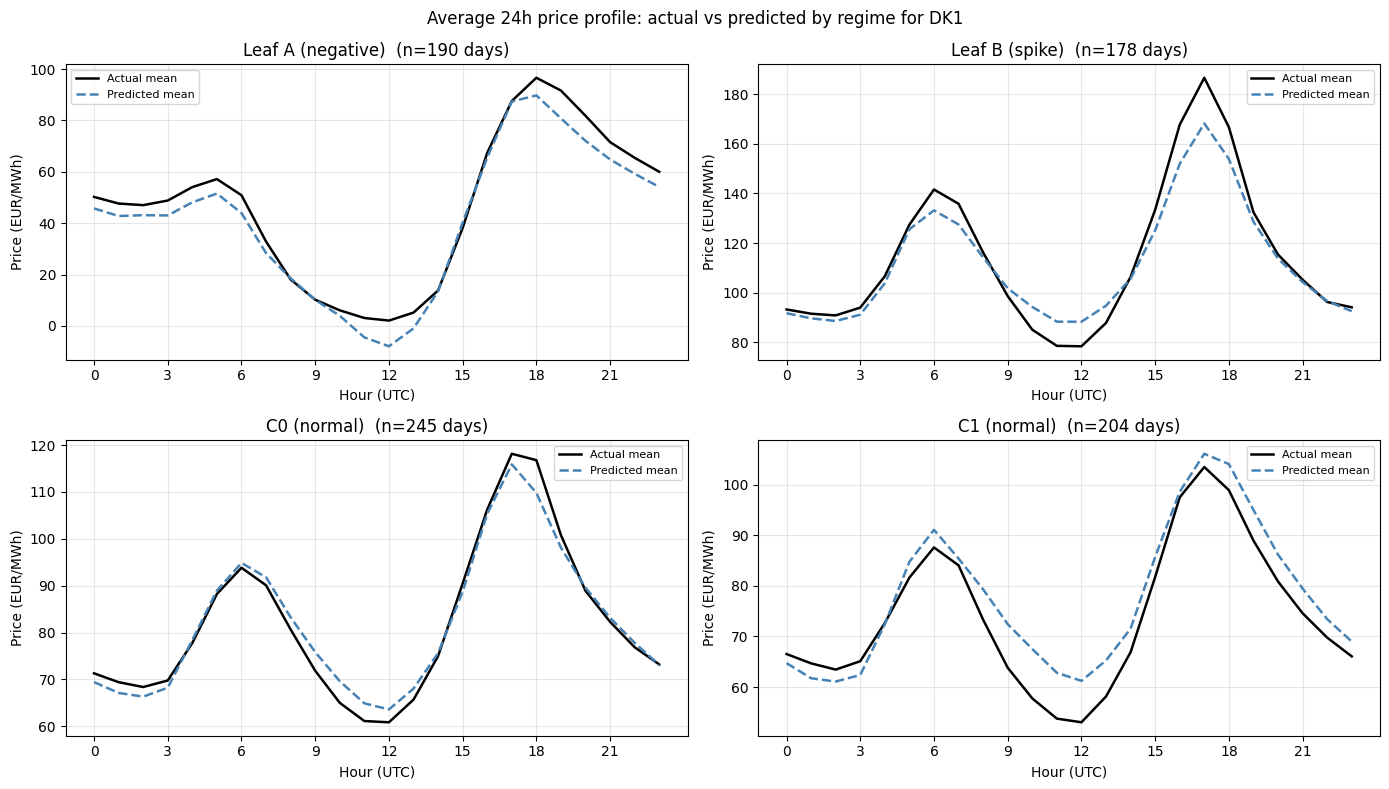

Saved: results/regime_profiles_actual_vs_predicted_DK1.png


In [25]:
plot_regime_profiles(df_preds,ZONES["DK1"])

### Error Distribution and Rolling WAPE

The error histogram shows whether prediction mistakes are symmetric around zero (no bias) or skewed (systematic over- or under-prediction). The rolling 30-day WAPE reveals whether accuracy is stable over time or degrades in specific periods, which can indicate a regime shift the model has not adapted to.

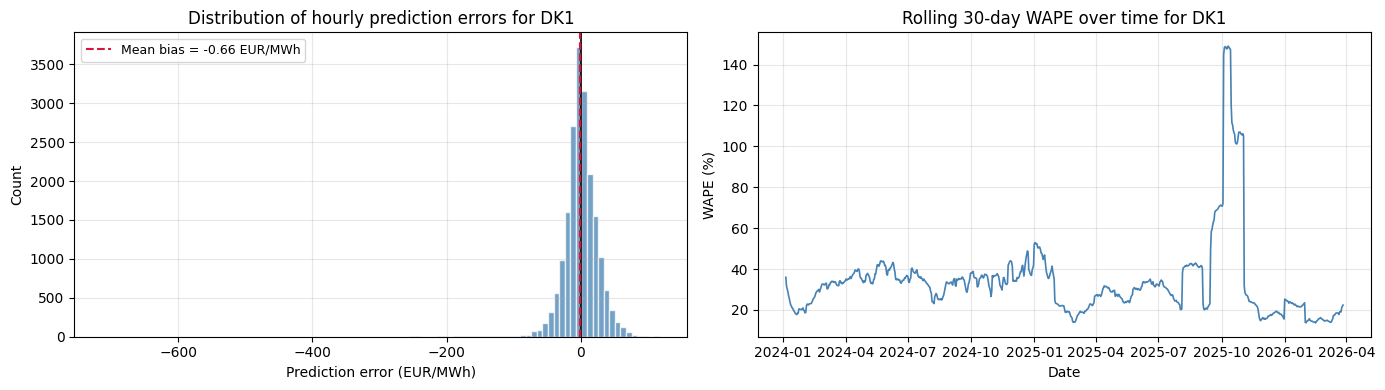

Saved: results/error_distribution_DK1.png
Mean error (bias):      -0.66 EUR/MWh
Error std:              28.38 EUR/MWh
Median absolute error:  12.95 EUR/MWh
90th pct absolute error:38.35 EUR/MWh


In [26]:
plot_error_distribution(df_preds, ZONES["DK1"])

### Classifier Regime Probabilities Over Time

The stacked area chart shows how the classifier allocates probability mass across the four regimes day by day. Persistent blue (Leaf A) bands indicate periods of sustained negative prices, red (Leaf B) bands indicate spike clustering. Wide green or orange areas reflect the dominant normal-day regimes. Sudden shifts in the colour mix can reveal structural changes in DK1 market conditions that fall outside the training distribution.

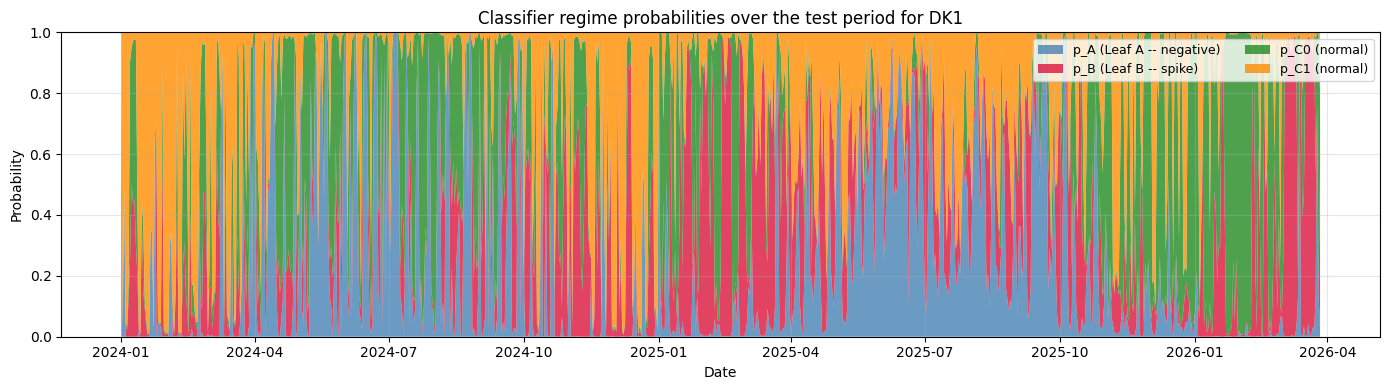

Saved: results/regime_probabilities_DK1.png


In [27]:
plot_regime_probabilities(df_preds, ZONES["DK1"])

### Best and Worst Predicted Days

Inspecting the individual days with the highest and lowest daily WAPE shows whether failures concentrate in specific market conditions or are scattered randomly. Clustered failures suggest a systematic gap in the feature set.

In [28]:
worst_best_days_wape(df_preds, ZONES["DK1"])

=== 10 worst predicted days for DK1 (by WAPE) ===
      date       regime_name   MAPE%   WAPE%  actual_mean_eur  pred_mean_eur
2025-10-04 Leaf A (negative) 9359.82 2210.43            -0.13          10.11
2025-09-15 Leaf A (negative) 9091.84  823.99             2.30          20.29
2025-08-05 Leaf A (negative) 4498.49  556.43            -0.04          19.96
2025-01-01 Leaf A (negative)  762.79  332.16             6.12          26.46
2026-01-01       C0 (normal)  739.77  302.43            15.44          62.14
2025-09-16 Leaf A (negative)  953.84  276.08             4.16          13.15
2024-11-24 Leaf A (negative) 1332.13  273.08             4.19          13.27
2024-11-01       C1 (normal)  409.89  252.26             9.87          32.97
2024-07-06 Leaf A (negative) 6205.52  160.40             9.31           8.94
2024-09-10 Leaf A (negative) 5827.20  150.42            18.25          41.56
=== 10 best predicted days for DK1 (by WAPE) ===
      date    regime_name  MAPE%  WAPE%  actual_mean_e

In [29]:
worst_best_days_mae(df_preds, ZONES["DK1"])

=== 10 worst predicted days for DK1 (by MAE) ===
      date    regime_name    MAE  MAPE%  WAPE%  actual_mean_eur  pred_mean_eur
2024-12-12 Leaf B (spike) 237.55  42.37  60.04           395.66         161.17
2024-12-11 Leaf B (spike) 108.46  33.23  42.40           255.80         148.68
2025-01-15 Leaf B (spike) 103.65  42.66  51.25           202.27          98.61
2025-11-25 Leaf B (spike)  84.42  30.20  40.65           207.70         124.42
2025-01-20 Leaf B (spike)  66.52  20.05  28.72           231.61         165.09
2025-01-16 Leaf B (spike)  62.14  74.02  65.46            94.93         157.07
2026-01-08    C0 (normal)  51.83  24.98  33.69           153.85         102.35
2024-11-05 Leaf B (spike)  47.40  18.37  30.04           157.81         121.06
2026-01-01    C0 (normal)  46.70 739.77 302.43            15.44          62.14
2025-07-01 Leaf B (spike)  44.64  21.69  32.13           138.92          97.40
=== 10 best predicted days for {zone_cfg.zone} (by MAE) ===
      date       regim

### Random Day Diagnostics


=== All features for 2026-03-17 (DK1) ===
  price_mean_lag1              76.6817
  price_std_lag1               52.8542
  price_min_lag1               13.2450
  price_max_lag1               177.0900
  price_neg_frac_lag1          0.0000
  was_negative_lag1            0.0000
  price_range_lag1             163.8450
  pivot_hour_peak_lag1         18.0000
  pivot_hour_trough_lag1       11.0000
  pivot_peak_sin               -1.0000
  pivot_peak_cos               -0.0000
  pivot_trough_sin             0.2588
  pivot_trough_cos             -0.9659
  price_roll3_mean             96.8753
  price_roll7_mean             86.2400
  neg_streak_length            0.0000
  spike_streak_length          1.0000
  ttf_lag1                     50.1150
  ttf_return_1d                0.0000
  ttf_return_3d                0.0025
  ttf_roll7_std                2.9095
  co2_lag1                     65.1050
  co2_return_1d                0.0000
  brent_return_3d              0.1213
  spark_spread_proxy         

C:\Users\amilo\AppData\Local\Temp\ipykernel_25424\4198487742.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


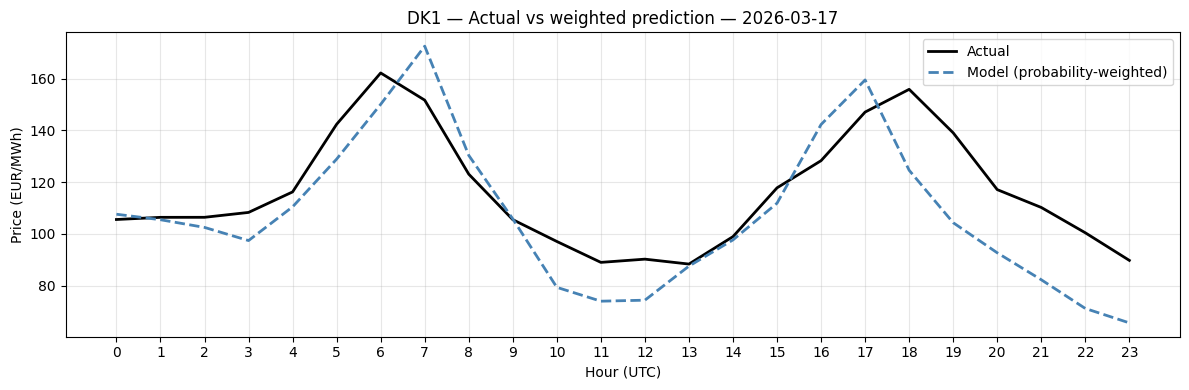

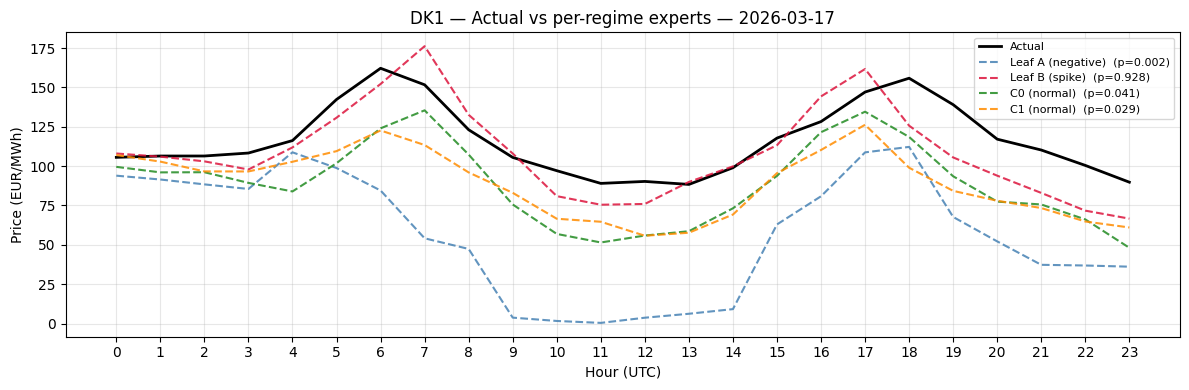

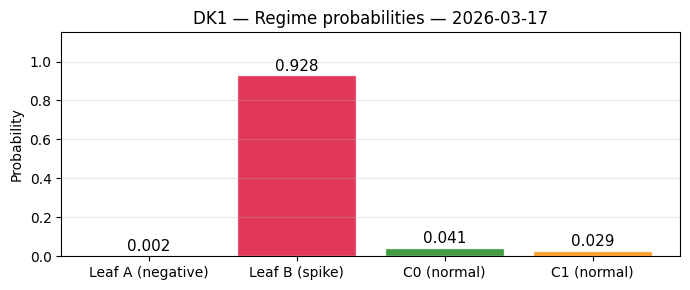

In [32]:
# Random test day
date = df_preds["date"].sample(random_state=0).iloc[0]


figs = plot_single_day_diagnostics(
    date, df_preds, all_fold_models, df_hourly, df_daily, ZONES["DK1"], model_cfg
)
for f in figs:
    f.show()   